# Order Flow Imbalance & Price Impact - First Results

**Question:** Does order flow imbalance (OFI) predict short-term price moves, and does that relationship differ between high- and low-volatility regimes?

Data: ~2 hours of Coinbase BTC-USD L2 order book, 1-second buckets, 5-second forward returns. OFI per Cont, Kukanov & Stoikov (2014).

In [26]:
import sys
from pathlib import Path

# Make the project root importable so `from src.ofi_study...` works from notebooks/
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.ofi_study.analysis import load, build_features, regress, directional_accuracy

print("imports ok, root:", project_root)

imports ok, root: /home/tyler/Documents/GitHub/ofi-regime-study


In [27]:
df = load(project_root / "data" / "btc" / "session.parquet")
frame = build_features(df)

print(f"{len(frame)} one-second observations")
print(frame["regime"].value_counts())
frame.head()

6896 one-second observations
regime
low     5208
high    1688
Name: count, dtype: int64


,ofi,mid,ret,fwd_ret,vol,regime
timestamp,,,,,,
2026-05-31 14:34:32+00:00,0.330793,73556.575,0.000009,0.000042,0.000056,low
2026-05-31 14:34:33+00:00,0.062777,73551.165,-0.000074,0.000115,0.000056,high
2026-05-31 14:34:34+00:00,0.031508,73551.165,0.000000,-0.000022,0.000056,low
2026-05-31 14:34:35+00:00,0.442581,73559.655,0.000115,-0.000137,0.000057,high
2026-05-31 14:34:36+00:00,0.036281,73559.655,0.000000,0.000198,0.000056,low


## Results: regression of 5-second forward return on OFI

Overall, then split by regime. HAC (Newey-West) standard errors correct for the overlap in forward returns.

In [28]:
def summarize(label, f):
    res = regress(f)
    acc, base = directional_accuracy(f)
    return {
        "regime": label,
        "n": len(f),
        "coef": res.params["ofi"],
        "t_stat": res.tvalues["ofi"],
        "p_value": res.pvalues["ofi"],
        "r_squared": res.rsquared,
        "dir_acc": acc,
        "baseline": base,
    }

results = pd.DataFrame([
    summarize("all", frame),
    summarize("low", frame[frame["regime"] == "low"]),
    summarize("high", frame[frame["regime"] == "high"]),
]).set_index("regime")

results.round(6)

,n,coef,t_stat,p_value,r_squared,dir_acc,baseline
regime,,,,,,,
all,6896,0.000022,4.226199,0.000024,0.011785,0.585191,0.536890
low,5208,0.000032,5.753764,0.000000,0.017464,0.588449,0.515074
high,1688,0.000012,1.932105,0.053347,0.006343,0.576355,0.596059


## Visualizing the result

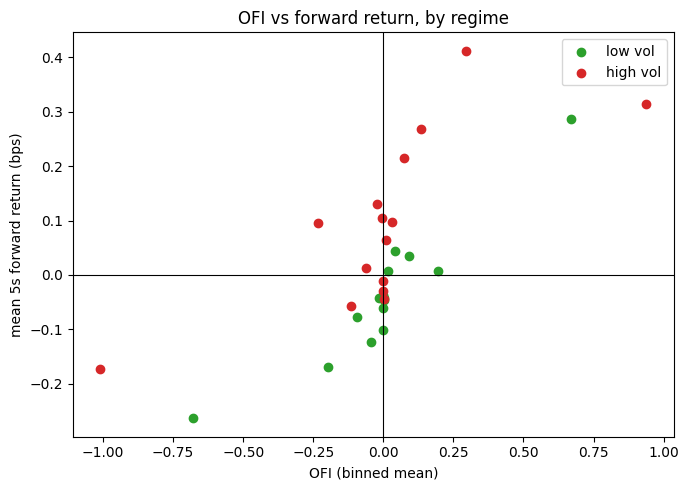

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

for regime, color in [("low", "tab:green"), ("high", "tab:red")]:
    sub = frame[frame["regime"] == regime]
    bins = pd.qcut(sub["ofi"], 15, duplicates="drop")
    binned = sub.groupby(bins, observed=True).agg(
        ofi=("ofi", "mean"), fwd_ret=("fwd_ret", "mean")
    )
    ax.scatter(binned["ofi"], binned["fwd_ret"] * 1e4, label=f"{regime} vol", color=color)

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("OFI (binned mean)")
ax.set_ylabel("mean 5s forward return (bps)")
ax.set_title("OFI vs forward return, by regime")
ax.legend()
plt.tight_layout()


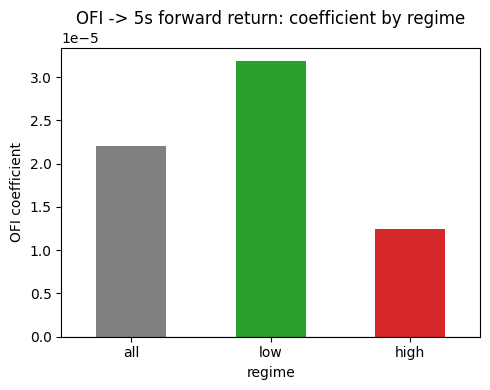

In [30]:
fig, ax = plt.subplots(figsize=(5, 4))
results["coef"].plot.bar(ax=ax, color=["gray", "tab:green", "tab:red"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("OFI coefficient")
ax.set_title("OFI -> 5s forward return: coefficient by regime")
plt.xticks(rotation=0)
plt.tight_layout()

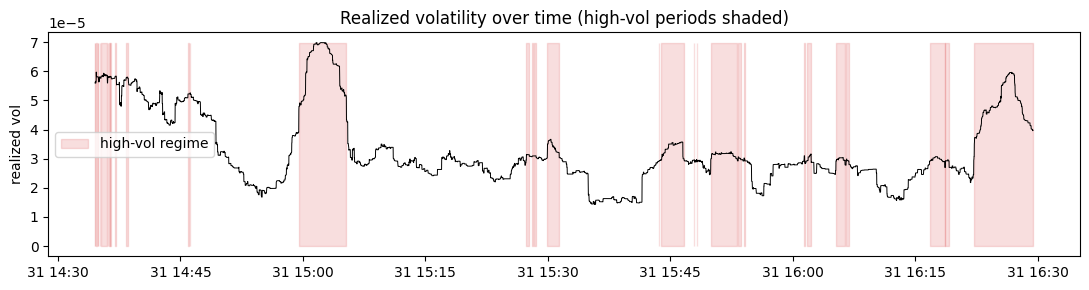

In [31]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(frame.index, frame["vol"], color="black", lw=0.7)
ax.fill_between(frame.index, 0, frame["vol"].max(),
                where=frame["regime"].eq("high"),
                color="tab:red", alpha=0.15, label="high-vol regime")
ax.set_title("Realized volatility over time (high-vol periods shaded)")
ax.set_ylabel("realized vol")
ax.legend()
plt.tight_layout()

## Findings

- OFI positively predicts 5-second forward returns (coef > 0, HAC t = 4.2 overall).
- The effect is **stronger and more significant in low-volatility regimes** (t = 5.8, beats directional baseline by ~7pts) than high vol (t = 1.9, not significant, no directional edge).
- Consistent with OFI being informative in orderly markets but drowned out by news/large trades when volatility is high.

**Limitations:** one 2-hour window, one asset (BTC-USD), level-1 OFI only.
Next: multi-day, multi-asset capture; multi-level OFI; Hawkes process.